In [1]:
import pandas as pd
import numpy as np
import csv
from collections import defaultdict

def load_wand_points_gui_style(file_path):
    """
    参考 WandCalibrator.load_wand_data_from_csv 和 
    RefractiveWandCalibrator._collect_observations 的逻辑进行读取
    """
    wand_points = defaultdict(lambda: defaultdict(list))
    
    with open(file_path, 'r', newline='') as f:
        reader = csv.reader(f)
        header = next(reader, None)
        if not header:
            print("Empty file")
            return None
            
        # Header 顺序: ["Frame", "Camera", "Status", "PointIdx", "X", "Y", "Radius", "Metric"]
        for row in reader:
            if len(row) < 8: continue
            
            try:
                f_idx = int(row[0])
                c_idx = int(row[1])
                status = row[2]
                pt_idx = int(row[3])
                x = float(row[4])
                y = float(row[5])
                r = float(row[6])
                m = float(row[7])
                
                # 仅加载 Filtered 状态的点（排除 Raw 点，模仿重构校准逻辑）
                if status.startswith("Filtered"):
                    wand_points[f_idx][c_idx].append([x, y, r, m, status, pt_idx])
            except (ValueError, IndexError): 
                continue

    # 将数据整理为 observations 结构 (模仿 _collect_observations)
    frames = sorted(wand_points.keys())
    # 获取所有涉及到的 Camera ID
    cam_ids = sorted(list(set(cid for f in wand_points.values() for cid in f.keys())))
    
    obsA = defaultdict(dict)       # obsA[frame][cam] = [x, y]
    obsB = defaultdict(dict)       # obsB[frame][cam] = [x, y]
    radii_small = defaultdict(dict) # radii_small[frame][cam] = r
    radii_large = defaultdict(dict) # radii_large[frame][cam] = r
    
    for fid in frames:
        for cid in cam_ids:
            pts = wand_points[fid].get(cid, [])
            for pt in pts:
                x, y, r, m, status, pt_idx = pt
                if status == "Filtered_Small":
                    obsA[fid][cid] = [x, y]
                    radii_small[fid][cid] = r
                elif status == "Filtered_Large":
                    obsB[fid][cid] = [x, y]
                    radii_large[fid][cid] = r
                    
    print(f"Loaded {len(frames)} frames for cams: {cam_ids}")
    return {
        "frames": frames,
        "cam_ids": cam_ids,
        "obsA": dict(obsA),
        "obsB": dict(obsB),
        "radii_small": dict(radii_small),
        "radii_large": dict(radii_large)
    }

# 路径设置
wand_points_path = r"H:\20260106\T0\wand_points3_filtered.csv"
dataset = load_wand_points_gui_style(wand_points_path)

# 打印第一帧样本进行验证
if dataset and dataset['frames']:
    fid0 = dataset['frames'][0]
    print(f"\nSample Frame {fid0} Data Summary:")
    for cid in dataset['cam_ids']:
        has_A = cid in dataset['obsA'].get(fid0, {})
        has_B = cid in dataset['obsB'].get(fid0, {})
        if has_A or has_B:
            info_A = f"Small={dataset['obsA'][fid0][cid]}" if has_A else "Small=N/A"
            info_B = f"Large={dataset['obsB'][fid0][cid]}" if has_B else "Large=N/A"
            print(f"  Cam {cid}: {info_A}, {info_B}")

Loaded 2331 frames for cams: [0, 1, 2]

Sample Frame 0 Data Summary:
  Cam 0: Small=[674.402, 489.376], Large=[824.829, 771.021]
  Cam 1: Small=[281.742, 482.818], Large=[592.633, 735.946]
  Cam 2: Small=[260.508, 418.651], Large=[573.791, 611.049]


In [4]:
def load_cameras():

    import os
    import openlpt as lpt

    # 路径设置：指向包含 cam0.txt, cam1.txt, cam2.txt 的目录
    cam_dir = r"H:\20260106\T0\Refraction\Calibration11\camFile"
    cams = {}

    # 加载相机 0, 1, 2
    for cid in [0, 1, 2]:
        cam_path = os.path.join(cam_dir, f"cam{cid}.txt")
        
        if os.path.exists(cam_path):
            # 创建 lpt Camera 对象
            cam = lpt.Camera()
            # 加载参数
            cam.loadParameters(cam_path)
            
            cams[cid] = cam
            print(f"Successfully loaded Cam {cid} from {cam_path}")
            print(f"  Type: {cam._type}")
            print(f"  Resolution: {cam.getNCol()}x{cam.getNRow()}")
        else:
            print(f"Error: Camera file not found: {cam_path}")

    # 验证 cams 字典
    print(f"\nTotal loaded cameras: {len(cams)}")
    return cams

cams = load_cameras()

Successfully loaded Cam 0 from H:\20260106\T0\Refraction\Calibration11\camFile\cam0.txt
  Type: CameraType.PINPLATE
  Resolution: 1280x800
Successfully loaded Cam 1 from H:\20260106\T0\Refraction\Calibration11\camFile\cam1.txt
  Type: CameraType.PINPLATE
  Resolution: 1280x800
Successfully loaded Cam 2 from H:\20260106\T0\Refraction\Calibration11\camFile\cam2.txt
  Type: CameraType.PINPLATE
  Resolution: 1280x800

Total loaded cameras: 3


In [3]:
import sys
import numpy as np

# 确保能导入项目内部模块
if '.' not in sys.path:
    sys.path.append('.')

from refractive_geometry import (
    build_pinplate_ray_cpp, triangulate_point, point_to_ray_dist
)

def reconstruct_and_analyze(fid, dataset, cams):
    """重构 A, B 点并输出重构误差（射线到 3D 点的距离）"""
    obs_info = [("Point A", dataset['obsA'].get(fid, {})), 
                ("Point B", dataset['obsB'].get(fid, {}))]
    
    results_3d = []
    
    print(f"--- Frame {fid} Reconstruction Analysis ---")
    
    for label, obs in obs_info:
        if not obs:
            results_3d.append(None)
            continue
            
        # 1. 建立折射射线
        rays = []
        for cid, uv in obs.items():
            if cid in cams:
                ray = build_pinplate_ray_cpp(cams[cid], uv)
                if ray.valid: rays.append(ray)
        
        if len(rays) < 2:
            print(f"  {label}: 重构失败（有效射线不足）")
            results_3d.append(None)
            continue
            
        # 2. 三角重构
        XA_np, cond, success, msg = triangulate_point(rays)
        
        # 3. 计算重构误差 (Point-to-Ray Distance)
        # 单位通常是 mm (取决于相机参数中的 t_vec 单位)
        recon_errors = [point_to_ray_dist(XA_np, r.o, r.d) for r in rays]
        mean_recon_err = np.mean(recon_errors)
        
        print(f"\n  {label}:")
        print(f"    3D Position: {XA_np}")
        print(f"    Ray Errors (mm): {['{:.4f}'.format(e) for e in recon_errors]}")
        print(f"    Mean Recon Error: {mean_recon_err:.6f} mm")
        
        results_3d.append(XA_np)
        
    return results_3d[0], results_3d[1]

# 执行并保存 3D 坐标供下一个 cell 使用
if dataset['frames']:
    test_fid = dataset['frames'][0]
    XA_3d, XB_3d = reconstruct_and_analyze(test_fid, dataset, cams)
    
    if XA_3d is not None and XB_3d is not None:
        L = np.linalg.norm(XA_3d - XB_3d)
        print(f"\nReconstructed Wand Length: {L:.4f} mm")


--- Frame 0 Reconstruction Analysis ---

  Point A:
    3D Position: [-7.16341918  0.74910333  0.58481186]
    Ray Errors (mm): ['0.0270', '0.0270']
    Mean Recon Error: 0.027048 mm

  Point B:
    3D Position: [0.09897391 6.99316483 3.52920805]
    Ray Errors (mm): ['0.0180', '0.0180']
    Mean Recon Error: 0.017990 mm

Reconstructed Wand Length: 10.0200 mm


In [4]:
import openlpt as lpt

def verify_projection(X_3d_np, obs_dict, cams, label):
    if X_3d_np is None:
        print(f"{label} is None, skipping verification.")
        return

    print(f"\n--- {label} Reprojection Analysis ---")
    pt_world = lpt.Pt3D(float(X_3d_np[0]), float(X_3d_np[1]), float(X_3d_np[2]))
    
    total_err = 0
    count = 0
    
    for cid, uv_obs in obs_dict.items():
        if cid in cams:
            # 使用 C++project 函数
            uv_proj_pt = cams[cid].project(pt_world)
            uv_proj = np.array([uv_proj_pt[0], uv_proj_pt[1]])
            
            err = np.linalg.norm(uv_proj - np.array(uv_obs))
            total_err += err
            count += 1
            print(f"  Cam {cid}: Obs={uv_obs}, Proj=[{uv_proj[0]:.3f}, {uv_proj[1]:.3f}], Err={err:.4f} px")
            
    if count > 0:
        print(f"  Mean Error: {total_err/count:.6f} px")

# 调用验证逻辑
if dataset['frames']:
    fid = dataset['frames'][0]
    verify_projection(XA_3d, dataset['obsA'][fid], cams, "Point A")
    verify_projection(XB_3d, dataset['obsB'][fid], cams, "Point B")


--- Point A Reprojection Analysis ---
  Cam 0: Obs=[674.402, 489.376], Proj=[674.059, 489.469], Err=0.3557 px
  Cam 1: Obs=[281.742, 482.818], Proj=[278.993, 483.897], Err=2.9530 px
  Cam 2: Obs=[260.508, 418.651], Proj=[263.229, 417.490], Err=2.9585 px
  Mean Error: 2.089070 px

--- Point B Reprojection Analysis ---
  Cam 0: Obs=[824.829, 771.021], Proj=[825.494, 772.813], Err=1.9117 px
  Cam 1: Obs=[592.633, 735.946], Proj=[591.725, 732.143], Err=3.9104 px
  Cam 2: Obs=[573.791, 611.049], Proj=[574.651, 613.291], Err=2.4010 px
  Mean Error: 2.741033 px


In [5]:
import numpy as np
from refractive_geometry import (
    build_pinplate_ray_cpp, triangulate_point, point_to_ray_dist
)
import openlpt as lpt

def project_and_reconstruct_check(X_3d_orig, cams, active_cids, label="Point"):
    if X_3d_orig is None:
        print(f"[{label}] Original 3D point is None. Skipping.")
        return

    print(f"\n=== {label} Consistency Check (3D -> 2D -> 3D) ===")
    print(f"  Original 3D: {X_3d_orig}")
    
    # 1. Project 3D -> 2D (Generate 'Perfect' Observations)
    proj_obs = {}
    pt_world_obj = lpt.Pt3D(float(X_3d_orig[0]), float(X_3d_orig[1]), float(X_3d_orig[2]))
    
    print("  [Step 1] Projected 2D Coords (Ideal):")
    for cid in active_cids:
        if cid in cams:
            uv = cams[cid].project(pt_world_obj)
            # Ensure list format [x, y] for verification
            proj_obs[cid] = [uv[0], uv[1]] 
            print(f"    Cam {cid}: {proj_obs[cid]}")

    # 2. Reconstruct 2D -> 3D (Refractive Triangulation)
    rays = []
    for cid, uv in proj_obs.items():
        # Build refractive ray from the PROJECTED coordinate
        ray = build_pinplate_ray_cpp(cams[cid], uv)
        if ray.valid:
            rays.append(ray)
    
    if len(rays) < 2:
        print("  [Error] Failed to build valid rays from projections.")
        return

    # Triangulate
    X_recon, cond, success, msg = triangulate_point(rays)
    
    if not success:
        print(f"  [Error] Triangulation failed: {msg}")
        return

    # 3. Compare & Metrics
    diff = X_recon - X_3d_orig
    dist_err = np.linalg.norm(diff)
    
    # Calculate Ray Errors (Self-consistency)
    recon_ray_errors = [point_to_ray_dist(X_recon, r.o, r.d) for r in rays]
    mean_ray_err = np.mean(recon_ray_errors)

    print("  [Step 2] Reconstructed 3D from Projections:")
    print(f"    New 3D: {X_recon}")
    print(f"    Diff (New - Orig): {diff}")
    print(f"    Euclidean Error: {dist_err:.6e} mm")
    print(f"    Mean Ray Discrepancy: {mean_ray_err:.6e} mm")
    
    if dist_err < 1e-4:
        print("  [RESULT] PASS (High Consistency)")
    else:
        print("  [RESULT] WARNING (Possible Refractive Logic Mismatch)")

# --- Run Check ---
if 'dataset' in locals() and dataset['frames']:
    # Get active camera IDs from the first frame's observations
    fid0 = dataset['frames'][0]
    
    # Check Point A
    active_cids_A = list(dataset['obsA'][fid0].keys())
    if 'XA_3d' in locals():
        project_and_reconstruct_check(XA_3d, cams, active_cids_A, "Point A")
        
    # Check Point B
    active_cids_B = list(dataset['obsB'][fid0].keys())
    if 'XB_3d' in locals():
        project_and_reconstruct_check(XB_3d, cams, active_cids_B, "Point B")


=== Point A Consistency Check (3D -> 2D -> 3D) ===
  Original 3D: [-0.94835303  1.33830623  7.09354285]
  [Step 1] Projected 2D Coords (Ideal):
    Cam 0: [674.0585719602892, 489.4686990109033]
    Cam 1: [278.99305450055795, 483.89657199335727]
    Cam 2: [263.2292769570525, 417.49018001118714]
  [Step 2] Reconstructed 3D from Projections:
    New 3D: [-0.9483511   1.33830495  7.09354347]
    Diff (New - Orig): [ 1.92469340e-06 -1.28555519e-06  6.26791540e-07]
    Euclidean Error: 2.397908e-06 mm
    Mean Ray Discrepancy: 1.196051e-06 mm
  [RESULT] PASS (High Consistency)

=== Point B Consistency Check (3D -> 2D -> 3D) ===
  Original 3D: [4.24164427 6.48229889 0.30211409]
  [Step 1] Projected 2D Coords (Ideal):
    Cam 0: [825.4941797048541, 772.8132873857903]
    Cam 1: [591.724676330767, 732.1425680108837]
    Cam 2: [574.6506230243301, 613.2908062126946]
  [Step 2] Reconstructed 3D from Projections:
    New 3D: [4.24164612 6.48229758 0.30211466]
    Diff (New - Orig): [ 1.85585916

In [6]:
def mtx_to_np(mtx):
    """手动将 MatrixDouble 转换为 numpy 数组"""
    rows = mtx.getDimRow()
    cols = mtx.getDimCol()
    res = np.zeros((rows, cols))
    for i in range(rows):
        for j in range(cols):
            # 使用 [i, j] 索引访问 (MatrixDouble 已绑定 __getitem__)
            res[i, j] = mtx[i, j]
    return res


def check_scale_and_magnification(XA_3d, cams):
    print("--- Scale & Magnification Analysis ---")
    for cid, cam in cams.items():
        # [CPP_PROTOCOL] 对于 PINPLATE 相机，直接访问 _pinplate_param
        # 它包含了继承自 PinholeParam 的 cam_mtx, r_mtx, t_vec
        if hasattr(cam, '_pinplate_param') and cam._type == lpt.CameraType.PINPLATE:
            pp = cam._pinplate_param
        else:
            pp = cam._pinhole_param
        
        # 1. 获取内参 f (cam_mtx[0,0])
        f = pp.cam_mtx[0, 0]
        
        # 2. 获取旋转矩阵 R 和位移向量 t (手动转 numpy)
        R = mtx_to_np(pp.r_mtx)
        t = np.array([pp.t_vec[i] for i in range(3)])
        
        # 3. 计算相机光心 C = -R^T * t
        C = -R.T @ t
        
        # 4. 计算 3D 点到相机中心的物理距离 (mm)
        dist_mm = np.linalg.norm(XA_3d - C)
        
        # 5. 比例：像素/毫米 (Magnification)
        px_per_mm = f / dist_mm
        
        print(f"  Cam {cid}:")
        print(f"    Focal Length: {f:.1f} px")
        print(f"    Distance to Pt: {dist_mm:.1f} mm")
        print(f"    Scale Ratio: {px_per_mm:.2f} px/mm")
        print(f"    Linear Mapping: 0.05mm error -> ~{0.05 * px_per_mm:.2f} px reproj error")

if XA_3d is not None:
    check_scale_and_magnification(XA_3d, cams)

--- Scale & Magnification Analysis ---
  Cam 0:
    Focal Length: 9009.8 px
    Distance to Pt: 205.5 mm
    Scale Ratio: 43.83 px/mm
    Linear Mapping: 0.05mm error -> ~2.19 px reproj error
  Cam 1:
    Focal Length: 8994.7 px
    Distance to Pt: 214.6 mm
    Scale Ratio: 41.91 px/mm
    Linear Mapping: 0.05mm error -> ~2.10 px reproj error
  Cam 2:
    Focal Length: 9009.0 px
    Distance to Pt: 216.1 mm
    Scale Ratio: 41.70 px/mm
    Linear Mapping: 0.05mm error -> ~2.08 px reproj error


In [7]:
if dataset['frames']:
    test_fid = dataset['frames'][0]
    XA_3d, XB_3d = reconstruct_and_analyze(test_fid, dataset, cams)
    
    if XA_3d is not None and XB_3d is not None:
        L = np.linalg.norm(XA_3d - XB_3d)
        print(f"\nReconstructed Wand Length: {L:.4f} mm")

--- Frame 0 Reconstruction Analysis ---

  Point A:
    3D Position: [-0.94835303  1.33830623  7.09354285]
    Ray Errors (mm): ['0.0079', '0.0696', '0.0711']
    Mean Recon Error: 0.049537 mm

  Point B:
    3D Position: [4.24164427 6.48229889 0.30211409]
    Ray Errors (mm): ['0.0405', '0.0924', '0.0584']
    Mean Recon Error: 0.063755 mm

Reconstructed Wand Length: 9.9760 mm


In [5]:
import numpy as np
from collections import defaultdict
import openlpt as lpt
import time
from refractive_geometry import (
    build_pinplate_ray_cpp, triangulate_point, point_to_ray_dist
)

def validate_and_compute_reprojection_errors_full(dataset, cams, tolerance_mm=1e-4):
    """
    1. 初次重构 3D (X_orig)
    2. 投影 (X_orig -> uv_proj)
    3. 二次重构 (uv_proj -> X_recon)
    4. 验证: |X_orig - X_recon| < tol AND MeanRayErr(X_recon) < tol
    5. 统计通过验证的点的投影误差 |uv_obs - uv_proj|
    """
    
    print(f"=== Full Dataset Verification (Tolerance: {tolerance_mm} mm) ===")
    
    reproj_errors = defaultdict(list)
    proj_times = []
    valid_points_count = 0
    skipped_points_count = 0
    total_points_processed = 0
    
    # helper to process one point dict (obsA or obsB)
    def process_point_set(obs_map, fid, label):
        nonlocal valid_points_count, skipped_points_count
        
        if fid not in obs_map: 
            return
            
        obs_dict = obs_map[fid]
        if not obs_dict or len(obs_dict) < 2:
            return

        # --- Step 1: Initial Reconstruction (Observation -> 3D Orig) ---
        rays_orig = []
        active_cids = []
        for cid, uv in obs_dict.items():
            if cid in cams:
                ray = build_pinplate_ray_cpp(cams[cid], uv)
                if ray.valid:
                    rays_orig.append(ray)
                    active_cids.append(cid)
        
        if len(rays_orig) < 2: return

        X_orig, _, success, _ = triangulate_point(rays_orig)
        if not success: return

        # --- Step 2: Projection (3D Orig -> uv_proj) ---
        pt_world = lpt.Pt3D(float(X_orig[0]), float(X_orig[1]), float(X_orig[2]))
        uv_proj_map = {}
        
        for cid in active_cids:
            # 理论投影点
            t0 = time.perf_counter()
            uv_p = cams[cid].project(pt_world)
            t1 = time.perf_counter()
            proj_times.append(t1 - t0)
            uv_proj_map[cid] = np.array([uv_p[0], uv_p[1]])

        # --- Step 3: Re-Reconstruction (uv_proj -> 3D Recon) ---
        rays_recon = []
        for cid, uv_p in uv_proj_map.items():
            # 使用投影点建立射线
            ray = build_pinplate_ray_cpp(cams[cid], uv_p)
            if ray.valid:
                rays_recon.append(ray)
        
        if len(rays_recon) < 2: return # Should not happen if Step 1 passed
        
        X_recon, _, success_recon, _ = triangulate_point(rays_recon)
        if not success_recon: return
        
        # --- Step 4: Validation Checks ---
        # A. Euclidean Consistency Error (Orig vs Recon)
        dist_consistency = np.linalg.norm(X_orig - X_recon)
        
        # B. Reconstruction Ray Error (of X_recon against theoretical rays)
        #    如果模型完美可逆，这个值应该极小
        recon_ray_dists = [point_to_ray_dist(X_recon, r.o, r.d) for r in rays_recon]
        mean_recon_err = np.mean(recon_ray_dists)
        
        # 判断是否有效
        if dist_consistency > tolerance_mm or mean_recon_err > tolerance_mm:
            # print(f"  [Skip Frame {fid} {label}] Failed check: Diff={dist_consistency:.4e}, ReconErr={mean_recon_err:.4e}")
            skipped_points_count += 1
            return
        
        # --- Step 5: Compute Reprojection Error (For Valid Points) ---
        # Error = |uv_obs - uv_proj|
        valid_points_count += 1
        
        for cid in active_cids:
            uv_obs = np.array(obs_dict[cid])
            uv_proj = uv_proj_map[cid]
            
            err_px = np.linalg.norm(uv_obs - uv_proj)
            reproj_errors[cid].append(err_px)

    # --- Main Loop ---
    frames = dataset['frames']
    for i, fid in enumerate(frames):
        process_point_set(dataset['obsA'], fid, "PtA")
        process_point_set(dataset['obsB'], fid, "PtB")
        total_points_processed += 1
        
        if i % 100 == 0:
            print(f"  Processed {i}/{len(frames)} frames...")

    # --- Statistics Output ---
    print(f"\n{'='*50}")
    print(f"Validation Summary")
    print(f"{'='*50}")
    print(f"Total Points Checked: {total_points_processed * 2} (approx)")
    print(f"Valid Points (Passed {tolerance_mm}mm Tol): {valid_points_count}")
    print(f"Skipped Points (Failed Consistency): {skipped_points_count}")
    print(f"Pass Rate: {valid_points_count / (valid_points_count + skipped_points_count + 1e-9) * 100:.2f}%")
    print(f"{'-'*50}")
    print(f"{'Cam ID':<8} | {'Mean (px)':<10} | {'Std (px)':<10} | {'Max (px)':<10} | {'Count':<8}")
    print(f"{'-'*50}")
    
    total_mean_errs = []
    
    sorted_cam_ids = sorted(reproj_errors.keys())
    for cid in sorted_cam_ids:
        errs = np.array(reproj_errors[cid])
        if len(errs) > 0:
            mean_e = np.mean(errs)
            std_e = np.std(errs)
            max_e = np.max(errs)
            count = len(errs)
            total_mean_errs.append(mean_e)
            
            print(f"{cid:<8} | {mean_e:<10.4f} | {std_e:<10.4f} | {max_e:<10.4f} | {count:<8}")
        else:
            print(f"{cid:<8} | {'N/A':<10} | {'N/A':<10} | {'N/A':<10} | {0:<8}")
            
    print(f"{'-'*50}")
    if total_mean_errs:
        print(f"Overall Mean Reprojection Error: {np.mean(total_mean_errs):.4f} px")

    if proj_times:
        proj_times_np = np.array(proj_times)
        mean_ms = np.mean(proj_times_np) * 1000.0
        std_ms = np.std(proj_times_np) * 1000.0
        max_ms = np.max(proj_times_np) * 1000.0
        print(f"Project Timing (per call): mean={mean_ms:.6f} ms | std={std_ms:.6f} ms | max={max_ms:.6f} ms | count={len(proj_times)}")

# Run It
t0 = time.perf_counter()
validate_and_compute_reprojection_errors_full(dataset, cams, tolerance_mm=1e-4)

t1 = time.perf_counter()
print(f"\nTotal Verification Time: {t1 - t0:.6f} seconds")

=== Full Dataset Verification (Tolerance: 0.0001 mm) ===
  Processed 0/2331 frames...
  Processed 100/2331 frames...
  Processed 200/2331 frames...
  Processed 300/2331 frames...
  Processed 400/2331 frames...
  Processed 500/2331 frames...
  Processed 600/2331 frames...
  Processed 700/2331 frames...
  Processed 800/2331 frames...
  Processed 900/2331 frames...
  Processed 1000/2331 frames...
  Processed 1100/2331 frames...
  Processed 1200/2331 frames...
  Processed 1300/2331 frames...
  Processed 1400/2331 frames...
  Processed 1500/2331 frames...
  Processed 1600/2331 frames...
  Processed 1700/2331 frames...
  Processed 1800/2331 frames...
  Processed 1900/2331 frames...
  Processed 2000/2331 frames...
  Processed 2100/2331 frames...
  Processed 2200/2331 frames...
  Processed 2300/2331 frames...

Validation Summary
Total Points Checked: 4662 (approx)
Valid Points (Passed 0.0001mm Tol): 4662
Skipped Points (Failed Consistency): 0
Pass Rate: 100.00%
--------------------------------

In [12]:
#optimization with Ray only

import numpy as np
import cv2
import openlpt as lpt
from scipy.optimize import least_squares
from refractive_geometry import (
    build_pinplate_ray_cpp, triangulate_point, point_to_ray_dist, 
    update_normal_tangent, update_cpp_camera_state
)

# --- 0. 配置与初始映射 (win0: cam0; win1: cam1, 2) ---
cam_to_window = {0: 0, 1: 1, 2: 1}
wand_length = 10.0
cam_params = {}
window_planes = {}
window_media = {}
cams_cpp = cams 

# --- 1. 参数提取与回拨修正 ---
for cid, cam in cams_cpp.items():
    pp = cam._pinplate_param
    pp.proj_nmax, pp.proj_tol = 1000, 1e-7
    cam._pinplate_param = pp
    cam.updatePinPlateParam()

    R = np.array([[pp.r_mtx[i,j] for j in range(3)] for i in range(3)])
    rvec, tvec = cv2.Rodrigues(R)[0], np.array([pp.t_vec[i] for i in range(3)])
    cp = [pp.cam_mtx[0,0], pp.cam_mtx[0,2], pp.cam_mtx[1,2], pp.dist_coeff[0], pp.dist_coeff[1]]
    cam_params[cid] = np.concatenate([rvec.flatten(), tvec, cp])
    
    wid = cam_to_window[cid]
    if wid not in window_planes:
        n_opt = np.array([pp.plane.norm_vector[0], pp.plane.norm_vector[1], pp.plane.norm_vector[2]])
        pt_farthest = np.array([pp.plane.pt[0], pp.plane.pt[1], pp.plane.pt[2]])
        thick = pp.w_array[0]
        window_planes[wid] = {'plane_pt': pt_farthest - n_opt * thick, 'plane_n': n_opt}
        refr = pp.refract_array
        window_media[wid] = {'thickness': thick, 'n_object': refr[0], 'n_window': refr[1], 'n_air': refr[2]}

# --- 3. 准备优化基准与变量 ---
active_cams = sorted(list(cam_params.keys()))
active_wins = sorted(list(window_planes.keys()))
anchors = {wid: window_planes[wid]['plane_pt'].copy() for wid in active_wins}
base_n = {wid: window_planes[wid]['plane_n'].copy() for wid in active_wins}
base_d = {wid: np.dot(window_planes[wid]['plane_n'], window_planes[wid]['plane_pt'] - anchors[wid]) for wid in active_wins}
base_ext = {cid: cam_params[cid][:6].copy() for cid in active_cams}

objective_call_count = 0
centers_base = {cid: (-cv2.Rodrigues(base_ext[cid][:3])[0].T @ base_ext[cid][3:]) for cid in active_cams}

# --- 3.5 估算全局物理基准 (基于相机参数) ---
px_target = 0.5           # 你设定的投影偏差目标 (px)
wand_tol_pct = 0.05       # 标定杆 1% 的容忍度

# 1. 计算平均焦距 (fx)
avg_f = np.mean([cam_params[cid][6] for cid in active_cams])

# 2. 计算平均物距 Z (从相机中心到 3D 点的平均距离)
sample_dists = []
for fid in dataset['frames'][::20]: # 抽样 5% 的帧
    for ep_key in ['obsA', 'obsB']:
        obs = dataset[ep_key].get(fid, {})
        rays = [build_pinplate_ray_cpp(cams_cpp[c], obs[c]) for c in obs if c in cams_cpp]
        rays = [r for r in rays if r.valid]
        if len(rays) >= 2:
            X, _, ok, _ = triangulate_point(rays)
            if ok:
                for cid in obs:
                    if cid in cams_cpp:
                        d = np.linalg.norm(X - centers_base[cid])
                        sample_dists.append(d)

avg_dist_z = np.mean(sample_dists) if sample_dists else 600.0 # 默认 600mm

# 3. 确定最终全局 Sigma (mm)
sigma_ray_global = px_target * (avg_dist_z / avg_f)
sigma_w = wand_length * wand_tol_pct

print(f"Computed Global sigma_ray: {sigma_ray_global:.4f} mm (Target {px_target}px at Z={avg_dist_z:.1f}mm)")
print(f"Computed Global sigma_wand: {sigma_w:.4f} mm ({wand_tol_pct*100:.1f}%)")
# 这里的比例就是关键
print(f"Global Weighting Ratio (Wand/Ray): {sigma_ray_global / sigma_w:.2f}")

# --- 4. 核心优化函数 (去除投影 Loss，保留日志) ---
def objective(x):
    global objective_call_count
    objective_call_count += 1
    
    # (a) 更新 C++ 状态
    curr_planes = {}
    for i, wid in enumerate(active_wins):
        dd, a, b = x[3*i : 3*i+3]
        n_new = update_normal_tangent(base_n[wid], a, b)
        curr_planes[wid] = {'pt': anchors[wid] + n_new * (base_d[wid] + dd), 'n': n_new}
    
    off = 3 * len(active_wins)
    for i, cid in enumerate(active_cams):
        dx = x[off + 6*i : off + 6*i+6]
        rv, tv = base_ext[cid][:3] + dx[:3], base_ext[cid][3:] + dx[3:]
        update_cpp_camera_state(cams_cpp[cid], extrinsics={'rvec':rv, 'tvec':tv}, 
                                plane_geom={'pt':curr_planes[cam_to_window[cid]]['pt'].tolist(), 
                                            'n':curr_planes[cam_to_window[cid]]['n'].tolist()})

    # (b) 残差计算初始化
    res, sr, sl, spr_px = [], 0.0, 0.0, 0.0
    nr, nl, npr = 0, 0, 0
    num_clipped, num_failed, all_sX, all_natural_lengths = 0, 0, [], []
    margin, rA, rB, w_side = 0.05, 1.5, 2.0, 5e4
    
    for fid in dataset['frames']:
        pts = []
        for ep_key, r_val in [('obsA', rA), ('obsB', rB)]:
            obs = dataset[ep_key].get(fid, {})
            # 这里的观察相机列表在整个优化过程中应保持一致
            cids_in_frame = [c for c in obs if c in cams_cpp]
            rays = [build_pinplate_ray_cpp(cams_cpp[c], obs[c]) for c in cids_in_frame]
            valid_rays = [r for r in rays if r.valid]
            
            X = None
            if len(valid_rays) >= 2:
                X, _, ok, _ = triangulate_point(valid_rays)
                if ok:
                    pts.append(X)
                    # 1. 射线重构误差 (加入 Loss)
                    for r in rays:
                        if r.valid:
                            d = point_to_ray_dist(X, r.o, r.d)
                            res.append(d/ sigma_ray_global); sr += d**2; nr += 1
                        else:
                            res.append(10.0) # 射线无效惩罚
                    
                    # 2. 投影误差 (仅用于日志记录，不加入 res)
                    pt_cpp = lpt.Pt3D(float(X[0]), float(X[1]), float(X[2]))
                    for cid in cids_in_frame:
                        uv_raw = cams_cpp[cid].project(pt_cpp)
                        uv_p = [float(uv_raw[0]), float(uv_raw[1])]
                        if np.all(np.isfinite(uv_p)) and abs(uv_p[0]) < 1e6:
                            err_u, err_v = obs[cid][0] - uv_p[0], obs[cid][1] - uv_p[1]
                            spr_px += err_u**2 + err_v**2; npr += 2
                            # 统计 Clip 状况，但结果不放入 res
                            mm_per_px = np.linalg.norm(X - centers_base[cid]) / cam_params[cid][6]
                            if abs(err_u * mm_per_px) > 5.0 or abs(err_v * mm_per_px) > 5.0:
                                num_clipped += 1
                        else:
                            num_failed += 1; spr_px += 500.0; npr += 2
                else: 
                    pts.append(None)
                    for _ in range(len(cids_in_frame)): res.append(10.0) # 三角化失败占位
            else: 
                pts.append(None)
                for _ in range(len(cids_in_frame)): res.append(10.0) # 射线不足占位

            # 3. 边界硬约束 (sX) - 必须保留，否则平面会跑飞
            for wid in active_wins:
                if X is not None:
                    sX = np.dot(curr_planes[wid]['n'], X - curr_planes[wid]['pt'])
                    all_sX.append(sX)
                    gap = (margin + r_val) - sX
                    if gap > 0:
                        clp = min(gap, 50.0)
                        res.extend([10.0 * (1.0 - np.exp(-clp/0.01)), w_side * clp])
                    else: res.extend([0.0, 0.0])
                else: res.extend([0.0, 0.0])

        # (d) 棒长残差 - 真正的软约束 (Soft Constraint)
        # 计算权重系数：Ray_RMSE / Expected_Wand_Error = 0.04 / 0.2 = 0.2
        
        if len(pts) == 2 and pts[0] is not None and pts[1] is not None:
            L_real = np.linalg.norm(pts[0]-pts[1])
            all_natural_lengths.append(L_real) 
            
            # 现在的残差是：误差值 * 0.2
            # 物理含义：当 Wand 长度偏离 0.2mm 时，产生的残差贡献（0.04）
            # 正好等于 Ray 偏离 0.04mm 时的残差贡献。两者在物理权重上达到了平等。
            res.append((L_real - wand_length)/ sigma_w) 
            
            sl += (L_real - wand_length)**2
            nl += 1
        else:
            res.append(0.0)

    # (c) 日志输出
    if objective_call_count % 5 == 0:
        ang = 0.0
        if len(active_wins) >= 2:
            n0, n1 = curr_planes[active_wins[0]]['n'], curr_planes[active_wins[1]]['n']
            ang = np.degrees(np.arccos(np.clip(np.dot(n0, n1), -1.0, 1.0)))
        msX = np.min(all_sX) if all_sX else 0.0
        avg_L = np.mean(all_natural_lengths) if all_natural_lengths else 0.0
        print(f"Iter {objective_call_count:3d} | Cost: {0.5*np.sum(np.square(res)):.4e} | "
              f"Ray RMSE: {np.sqrt(sr/max(1,nr)):.4f}mm | Len: {avg_L:.4f}mm | "
              f"Proj RMSE: {np.sqrt(spr_px/max(1,npr)):.3f}px | min(sX): {msX:.3f} | Angle: {ang:.4f} | "
              f"Bad:(C:{num_clipped},F:{num_failed})")
    
    return np.array(res)

# --- 5. 执行联合优化 ---
x0 = np.zeros(3 * len(active_wins) + 6 * len(active_cams))
lb, ub = [], []
for _ in active_wins: lb.extend([-5, -np.radians(2.5), -np.radians(2.5)]); ub.extend([5, np.radians(2.5), np.radians(2.5)])
for _ in active_cams: lb.extend([-np.radians(10)]*3 + [-20.0]*3); ub.extend([np.radians(10)]*3 + [20.0]*3)

print("Starting Ray-Only Joint Optimization...")
result = least_squares(objective, x0, bounds=(lb, ub), method='trf', ftol=1e-5, max_nfev=50)

# --- 6. 结果提交 ---
final_x = result.x
for i, wid in enumerate(active_wins):
    dd, a, b = final_x[3*i : 3*i+3]
    n_new = update_normal_tangent(base_n[wid], a, b)
    window_planes[wid]['plane_n'], window_planes[wid]['plane_pt'] = n_new, anchors[wid] + n_new * (base_d[wid] + dd)
off = 3 * len(active_wins)
for i, cid in enumerate(active_cams):
    cam_params[cid][:6] += final_x[off + 6*i : off + 6*i+6]
print("\nOptimization Finished & Results Committed.")

Computed Global sigma_ray: 0.0117 mm (Target 0.5px at Z=212.2mm)
Computed Global sigma_wand: 0.5000 mm (5.0%)
Global Weighting Ratio (Wand/Ray): 0.02
Starting Ray-Only Joint Optimization...
Iter   5 | Cost: 7.0456e+04 | Ray RMSE: 0.0373mm | Len: 9.9958mm | Proj RMSE: 1.150px | min(sX): 4.367 | Angle: 92.2317 | Bad:(C:0,F:0)
Iter  10 | Cost: 7.0456e+04 | Ray RMSE: 0.0373mm | Len: 9.9958mm | Proj RMSE: 1.150px | min(sX): 4.367 | Angle: 92.2317 | Bad:(C:0,F:0)
Iter  15 | Cost: 7.0456e+04 | Ray RMSE: 0.0373mm | Len: 9.9958mm | Proj RMSE: 1.150px | min(sX): 4.367 | Angle: 92.2317 | Bad:(C:0,F:0)
Iter  20 | Cost: 7.0456e+04 | Ray RMSE: 0.0373mm | Len: 9.9958mm | Proj RMSE: 1.150px | min(sX): 4.367 | Angle: 92.2317 | Bad:(C:0,F:0)
Iter  25 | Cost: 7.0456e+04 | Ray RMSE: 0.0373mm | Len: 9.9958mm | Proj RMSE: 1.150px | min(sX): 4.367 | Angle: 92.2317 | Bad:(C:0,F:0)
Iter  30 | Cost: 6.9188e+04 | Ray RMSE: 0.0370mm | Len: 9.9829mm | Proj RMSE: 1.140px | min(sX): 4.004 | Angle: 92.3087 | Bad:(C:0

KeyboardInterrupt: 

In [16]:
import numpy as np
import cv2
import openlpt as lpt
from scipy.optimize import least_squares
from refractive_geometry import (
    build_pinplate_ray_cpp, triangulate_point, point_to_ray_dist, 
    update_normal_tangent, update_cpp_camera_state
)

# --- 0. 配置与初始映射 (win0: cam0; win1: cam1, 2) ---
cam_to_window = {0: 0, 1: 1, 2: 1}
wand_length = 10.0
cam_params = {}
window_planes = {}
window_media = {}
cams_cpp = cams 

# --- 1. 参数提取与回拨修正 (解决 Double-Shift) 与 搜索器增强 ---
for cid, cam in cams_cpp.items():
    pp = cam._pinplate_param
    
    # A. 增强投影搜索器 (提高在 90° 极端位置的收敛成功率)
    pp.proj_nmax = 1000 
    pp.proj_tol = 1e-7
    cam._pinplate_param = pp
    cam.updatePinPlateParam()

    # B. 提取位姿与内参
    R = np.array([[pp.r_mtx[i,j] for j in range(3)] for i in range(3)])
    rvec, _ = cv2.Rodrigues(R)
    tvec = np.array([pp.t_vec[i] for i in range(3)])
    cp = [pp.cam_mtx[0,0], pp.cam_mtx[0,2], pp.cam_mtx[1,2], pp.dist_coeff[0], pp.dist_coeff[1]]
    cam_params[cid] = np.concatenate([rvec.flatten(), tvec, cp])
    
    # C. 提取并修正平面 (解决 Double-Shift)
    wid = cam_to_window[cid]
    if wid not in window_planes:
        # 使用索引访问 [0,1,2] 代替 .x.y.z
        n_opt = np.array([pp.plane.norm_vector[0], pp.plane.norm_vector[1], pp.plane.norm_vector[2]])
        pt_farthest = np.array([pp.plane.pt[0], pp.plane.pt[1], pp.plane.pt[2]])
        thick = pp.w_array[0]
        
        # 将点从最远界面回拨到最近界面
        pt_opt = pt_farthest - n_opt * thick
        
        window_planes[wid] = {'plane_pt': pt_opt, 'plane_n': n_opt}
        refr = pp.refract_array
        window_media[wid] = {
            'thickness': thick,
            'n_object': refr[0], 'n_window': refr[1], 'n_air': refr[2]
        }

# # --- 2. 方案 A: 强制正交归位 (重置起点为 90°) ---
# if 0 in window_planes and 1 in window_planes:
#     n1 = window_planes[1]['plane_n']
#     n0_old = window_planes[0]['plane_n']
#     n0_ortho = n0_old - np.dot(n0_old, n1) * n1
#     n0_ortho /= np.linalg.norm(n0_ortho)
#     window_planes[0]['plane_n'] = n0_ortho
#     print(f"[方案 A] Win0 已强行重置为 90° 正交位。")

# --- 3. 准备优化基准与变量 ---
active_cams = sorted(list(cam_params.keys()))
active_wins = sorted(list(window_planes.keys()))
anchors = {wid: window_planes[wid]['plane_pt'].copy() for wid in active_wins}
base_n = {wid: window_planes[wid]['plane_n'].copy() for wid in active_wins}
base_d = {wid: np.dot(window_planes[wid]['plane_n'], window_planes[wid]['plane_pt'] - anchors[wid]) for wid in active_wins}
base_ext = {cid: cam_params[cid][:6].copy() for cid in active_cams}

objective_call_count = 0
centers_base = {} 
for cid in active_cams:
    rv, tv = base_ext[cid][:3], base_ext[cid][3:]
    R = cv2.Rodrigues(rv)[0]
    centers_base[cid] = -R.T @ tv

# --- 4. 核心优化函数 ---
def objective(x):
    global objective_call_count
    objective_call_count += 1
    
    # (a) 更新 C++ 状态
    curr_planes = {}
    for i, wid in enumerate(active_wins):
        dd, a, b = x[3*i : 3*i+3]
        n_new = update_normal_tangent(base_n[wid], a, b)
        curr_planes[wid] = {'pt': anchors[wid] + n_new * (base_d[wid] + dd), 'n': n_new}
    
    off = 3 * len(active_wins)
    for i, cid in enumerate(active_cams):
        dx = x[off + 6*i : off + 6*i+6]
        rv, tv = base_ext[cid][:3] + dx[:3], base_ext[cid][3:] + dx[3:]
        wid = cam_to_window[cid]
        update_cpp_camera_state(cams_cpp[cid], extrinsics={'rvec':rv, 'tvec':tv}, 
                                plane_geom={'pt':curr_planes[wid]['pt'].tolist(), 'n':curr_planes[wid]['n'].tolist()})

    # (b) 残差计算初始化
    res = []
    sr, sl, spr_px = 0.0, 0.0, 0.0 # sr: Ray(mm^2), sl: Len(mm^2), spr_px: Proj(px^2)
    nr, nl, npr = 0, 0, 0
    num_clipped, num_failed = 0, 0
    all_sX = []
    all_natural_lengths = [] # 新增这行
    
    margin, rA, rB, w_side = 0.05, 1.5, 2.0, 5e4
    
    for fid in dataset['frames']: # 提示：为加速可使用 [::5]
        pts = []
        for ep_key, r_val in [('obsA', rA), ('obsB', rB)]:
            obs = dataset[ep_key].get(fid, {})
            rays = [build_pinplate_ray_cpp(cams_cpp[c], obs[c]) for c in obs if c in cams_cpp]
            rays = [r for r in rays if r.valid]
            
            X = None
            if len(rays) >= 2:
                X, _, ok, _ = triangulate_point(rays)
                if ok:
                    pts.append(X)
                    # 1. 射线重构误差 (mm)
                    for r in rays:
                        d = point_to_ray_dist(X, r.o, r.d)
                        res.append(d); sr += d**2; nr += 1
                    
                    # 2. 投影误差 (Px -> mm)
                    pt_cpp = lpt.Pt3D(float(X[0]), float(X[1]), float(X[2]))
                    for cid in obs:
                        if cid in cams_cpp:
                            uv_raw = cams_cpp[cid].project(pt_cpp)
                            uv_p = [float(uv_raw[0]), float(uv_raw[1])]
                            
                            if np.all(np.isfinite(uv_p)) and abs(uv_p[0]) < 1e6:
                                # 记录像素偏差以便日志统计
                                err_u, err_v = obs[cid][0] - uv_p[0], obs[cid][1] - uv_p[1]
                                spr_px += err_u**2 + err_v**2; npr += 2
                                
                                # 物理缩放 px -> mm
                                mm_per_px = np.linalg.norm(X - centers_base[cid]) / cam_params[cid][6]
                                du_mm, dv_mm = err_u * mm_per_px, err_v * mm_per_px
                                
                                # 数值保护 (限制单点贡献最大为 5mm)
                                if abs(du_mm) > 5.0 or abs(dv_mm) > 5.0:
                                    num_clipped += 1
                                du_c, dv_c = np.clip(du_mm, -5.0, 5.0), np.clip(dv_mm, -5.0, 5.0)
                                res.extend([du_c, dv_c])
                            else:
                                # 搜索失败，给一个较大的固定惩罚 (5mm)
                                num_failed += 1
                                res.extend([5.0, 5.0]); spr_px += 500.0; npr += 2 # 失败按约 20px 计算
                else: 
                    pts.append(None)
                    for _ in range(len(obs)): res.extend([0.0, 0.0])
            else: 
                pts.append(None)
                for _ in range(len(obs)): res.extend([0.0, 0.0])

            # 3. 边界硬约束 (sX)
            for wid in active_wins:
                if X is not None:
                    sX = np.dot(curr_planes[wid]['n'], X - curr_planes[wid]['pt'])
                    all_sX.append(sX)
                    gap = (margin + r_val) - sX
                    if gap > 0:
                        clp = min(gap, 50.0)
                        res.append(10.0 * (1.0 - np.exp(-clp/0.01))); res.append(w_side * clp)
                    else: res.extend([0.0, 0.0])
                else: res.extend([0.0, 0.0])

        # 4. 棒长约束 (mm)
        if len(pts) == 2 and pts[0] is not None and pts[1] is not None:
            L_real = np.linalg.norm(pts[0]-pts[1])
            # 记录当前自然演变出的长度
            all_natural_lengths.append(L_real) 
            
            
            # 或者 方案二：保留极小权重，仅防止解跑太偏
            res.append((L_real - wand_length))
            
            sl += (L_real - wand_length)**2
            nl += 1
        else:
            res.append(0.0)

    # (c) 指标输出
    if objective_call_count % 5 == 0:
        ang = 0.0
        if len(active_wins) >= 2:
            n0, n1 = curr_planes[active_wins[0]]['n'], curr_planes[active_wins[1]]['n']
            ang = np.degrees(np.arccos(np.clip(np.dot(n0, n1), -1.0, 1.0)))
        msX = np.min(all_sX) if all_sX else 0.0
        
        avg_L = np.mean(all_natural_lengths) if all_natural_lengths else 0.0
        print(f"Iter {objective_call_count:3d} | Cost: {0.5*np.sum(np.square(res)):.4e} | "
              f"Ray RMSE: {np.sqrt(sr/max(1,nr)):.4f}mm | " 
              f"Len: {avg_L:.4f}mm | "
              f"Proj RMSE: {np.sqrt(spr_px/max(1,npr)):.3f}px | "
              f"min(sX): {msX:.3f} | Angle: {ang:.4f} | "
              f"Bad:(C:{num_clipped},F:{num_failed})")
    
    return np.array(res)

# --- 5. 执行联合优化 ---
x0 = np.zeros(3 * len(active_wins) + 6 * len(active_cams))
lb, ub = [], []
for _ in active_wins: lb.extend([-50.0, -np.radians(30), -np.radians(30)]); ub.extend([50.0, np.radians(30), np.radians(30)])
for _ in active_cams: lb.extend([-np.radians(20)]*3 + [-10.0]*3); ub.extend([np.radians(20)]*3 + [10.0]*3)

print("Starting Joint BA Optimization...")
result = least_squares(objective, x0, bounds=(lb, ub), method='trf', ftol=1e-6, max_nfev=60)

# --- 6. 结果提交 (使下次运行能接续结果) ---
final_x = result.x
for i, wid in enumerate(active_wins):
    dd, a, b = final_x[3*i : 3*i+3]
    n_new = update_normal_tangent(base_n[wid], a, b)
    window_planes[wid]['plane_n'] = n_new
    window_planes[wid]['plane_pt'] = anchors[wid] + n_new * (base_d[wid] + dd)
off = 3 * len(active_wins)
for i, cid in enumerate(active_cams):
    cam_params[cid][:6] += final_x[off + 6*i : off + 6*i+6]
print("\nOptimization Finished & Results Committed.")

Starting Joint BA Optimization...
Iter   5 | Cost: 2.2992e+01 | Ray RMSE: 0.0373mm | Len: 9.9958mm | Proj RMSE: 1.150px | min(sX): 4.367 | Angle: 92.2317 | Bad:(C:0,F:0)
Iter  10 | Cost: 2.2992e+01 | Ray RMSE: 0.0373mm | Len: 9.9958mm | Proj RMSE: 1.150px | min(sX): 4.367 | Angle: 92.2317 | Bad:(C:0,F:0)
Iter  15 | Cost: 2.2992e+01 | Ray RMSE: 0.0373mm | Len: 9.9958mm | Proj RMSE: 1.150px | min(sX): 4.367 | Angle: 92.2317 | Bad:(C:0,F:0)
Iter  20 | Cost: 2.2992e+01 | Ray RMSE: 0.0373mm | Len: 9.9958mm | Proj RMSE: 1.150px | min(sX): 4.367 | Angle: 92.2317 | Bad:(C:0,F:0)
Iter  25 | Cost: 2.2992e+01 | Ray RMSE: 0.0373mm | Len: 9.9958mm | Proj RMSE: 1.150px | min(sX): 4.367 | Angle: 92.2317 | Bad:(C:0,F:0)
Iter  30 | Cost: 2.2901e+01 | Ray RMSE: 0.0373mm | Len: 9.9950mm | Proj RMSE: 1.149px | min(sX): 4.223 | Angle: 92.8862 | Bad:(C:0,F:0)
Iter  35 | Cost: 2.2901e+01 | Ray RMSE: 0.0373mm | Len: 9.9950mm | Proj RMSE: 1.149px | min(sX): 4.223 | Angle: 92.8862 | Bad:(C:0,F:0)
Iter  40 | Cos

In [8]:
from collections import defaultdict

def evaluate_final_reprojection_errors_robust(dataset, cams_cpp, cam_params):
    print("Evaluating robust reprojection errors...")
    reproj_errors = defaultdict(list)
    total_points = 0
    fail_count = 0
    clip_count = 0

    for fid in dataset['frames']:
        for ep_key in ['obsA', 'obsB']:
            obs = dataset[ep_key].get(fid, {})
            if len(obs) < 2: continue
            
            rays = []
            for cid, uv in obs.items():
                if cid in cams_cpp:
                    r = build_pinplate_ray_cpp(cams_cpp[cid], uv)
                    if r.valid: rays.append(r)
            
            if len(rays) >= 2:
                X, _, ok, _ = triangulate_point(rays)
                if not ok: continue
                
                total_points += 1
                pt_cpp = lpt.Pt3D(float(X[0]), float(X[1]), float(X[2]))
                
                for cid, uv_obs in obs.items():
                    if cid in cams_cpp:
                        uv_raw = cams_cpp[cid].project(pt_cpp)
                        uv_p = [float(uv_raw[0]), float(uv_raw[1])]
                        
                        # --- 安全检查：过滤掉天文数字 ---
                        if np.all(np.isfinite(uv_p)) and abs(uv_p[0]) < 1e6:
                            err = np.linalg.norm(np.array(uv_obs) - np.array(uv_p))
                            # 记录正常点
                            if err < 100.0: # 100px 以上通常视为该帧失效
                                reproj_errors[cid].append(err)
                            else:
                                clip_count += 1
                        else:
                            fail_count += 1

    print("\n" + "="*65)
    print(f"{'Cam ID':^8} | {'Mean (px)':^10} | {'Std (px)':^10} | {'Max (px)':^10} | {'Count':^8}")
    print("-" * 65)
    
    grand_total_errs = []
    for cid in sorted(reproj_errors.keys()):
        errs = np.array(reproj_errors[cid])
        if len(errs) > 0:
            m, s, mx = np.mean(errs), np.std(errs), np.max(errs)
            grand_total_errs.extend(errs.tolist())
            print(f"{cid:^8} | {m:^10.4f} | {s:^10.4f} | {mx:^10.4f} | {len(errs):^8}")
        else:
            print(f"{cid:^8} | {'N/A':^10} | {'N/A':^10} | {'N/A':^10} | {0:^8}")
    
    print("-" * 65)
    if grand_total_errs:
        print(f"Overall Mean Error: {np.mean(grand_total_errs):.4f} px")
    print(f"Total Valid Points: {total_points}")
    print(f"Failed/Exploded Projections: {fail_count} (Filtered out)")
    print(f"Outliers (>100px): {clip_count}")
    print("="*65)

evaluate_final_reprojection_errors_robust(dataset, cams_cpp, cam_params)

Evaluating robust reprojection errors...

 Cam ID  | Mean (px)  |  Std (px)  |  Max (px)  |  Count  
-----------------------------------------------------------------
   0     |   1.3725   |   1.1617   |   8.2854   |   4662  
   1     |   1.1042   |   0.7125   |   5.9083   |   4662  
   2     |   1.3332   |   0.8958   |   5.9124   |   4661  
-----------------------------------------------------------------
Overall Mean Error: 1.2699 px
Total Valid Points: 4662
Failed/Exploded Projections: 1 (Filtered out)
Outliers (>100px): 0


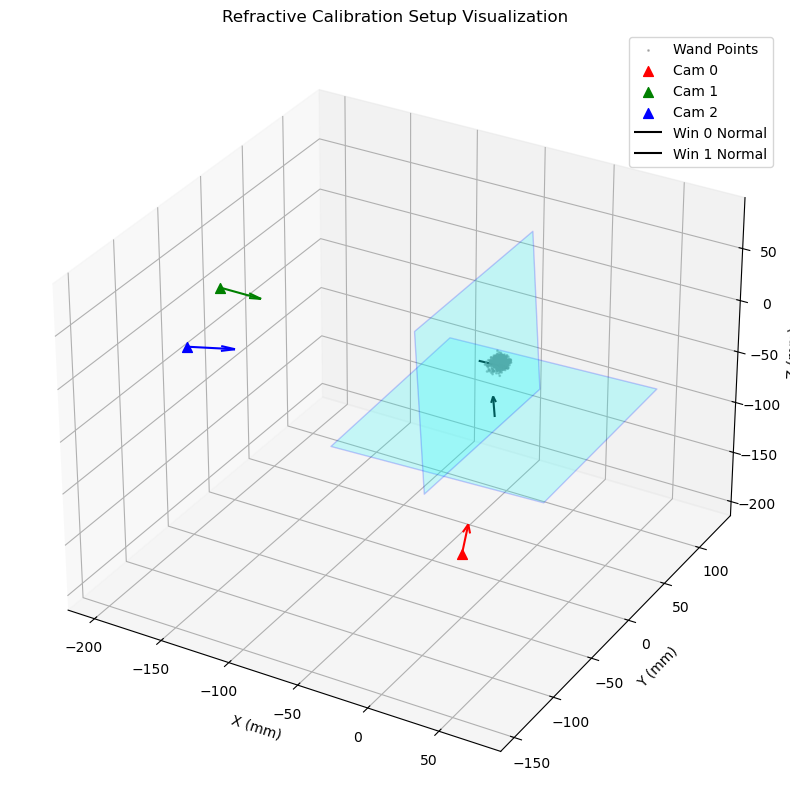

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import cv2

def visualize_calibration_setup(dataset, cam_params, window_planes, cams_cpp, sample_rate=10):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # --- 1. 绘制 3D 点云 ---
    all_pts = []
    for fid in dataset['frames'][::sample_rate]: # 采样以提升绘图速度
        for ep in ['obsA', 'obsB']:
            obs = dataset[ep].get(fid, {})
            rays = []
            for cid, uv in obs.items():
                if cid in cams_cpp:
                    r = build_pinplate_ray_cpp(cams_cpp[cid], uv)
                    if r.valid: rays.append(r)
            if len(rays) >= 2:
                X, _, ok, _ = triangulate_point(rays)
                if ok: all_pts.append(X)
                
    if all_pts:
        all_pts = np.array(all_pts)
        ax.scatter(all_pts[:,0], all_pts[:,1], all_pts[:,2], s=1, c='gray', alpha=0.5, label='Wand Points')

    # --- 2. 绘制相机与光轴 ---
    colors = ['red', 'green', 'blue', 'orange', 'purple']
    for i, cid in enumerate(sorted(cam_params.keys())):
        p = cam_params[cid]
        R = cv2.Rodrigues(p[0:3])[0]
        C = -R.T @ p[3:6]  # 相机光心
        axis_dir = R.T @ np.array([0, 0, 30.0]) # 绘制 30mm 长度的光轴方向
        
        ax.scatter(C[0], C[1], C[2], color=colors[i % len(colors)], s=50, marker='^', label=f'Cam {cid}')
        ax.quiver(C[0], C[1], C[2], axis_dir[0], axis_dir[1], axis_dir[2], 
                  color=colors[i % len(colors)], arrow_length_ratio=0.3)

    # --- 3. 绘制折射平面 (半透明) ---
    for wid, pl in window_planes.items():
        n = pl['plane_n']
        pt = pl['plane_pt']
        
        # 创建一个局部的平面网格 (大小设为 150mm x 150mm)
        d = 75.0
        # 寻找平面的基向量
        v1 = np.array([1, 0, 0]) if abs(n[0]) < 0.9 else np.array([0, 1, 0])
        v1 = np.cross(n, v1)
        v1 /= np.linalg.norm(v1)
        v2 = np.cross(n, v1)
        
        # 生成四个顶点的坐标
        corners = np.array([
            pt - d*v1 - d*v2,
            pt + d*v1 - d*v2,
            pt + d*v1 + d*v2,
            pt - d*v1 + d*v2
        ])
        
        from mpl_toolkits.mplot3d.art3d import Poly3DCollection
        poly = Poly3DCollection([corners], alpha=0.2, facecolor='cyan', edgecolor='blue')
        ax.add_collection3d(poly)
        # 绘制法向量预览
        ax.quiver(pt[0], pt[1], pt[2], n[0]*20, n[1]*20, n[2]*20, color='black', label=f'Win {wid} Normal')

    # --- 设置视图属性 ---
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_zlabel('Z (mm)')
    ax.set_title('Refractive Calibration Setup Visualization')
    ax.legend()
    
        # 自动调整比例，使坐标轴各向同性 (NumPy 2.0+ 兼容版)
    limits = np.array([ax.get_xlim(), ax.get_ylim(), ax.get_zlim()])
    # 计算三个轴各自的跨度
    spans = limits[:, 1] - limits[:, 0]
    max_range = spans.max() / 2.0
    
    mid_x, mid_y, mid_z = np.mean(limits[0]), np.mean(limits[1]), np.mean(limits[2])
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.show()

# 运行绘图
visualize_calibration_setup(dataset, cam_params, window_planes, cams_cpp)

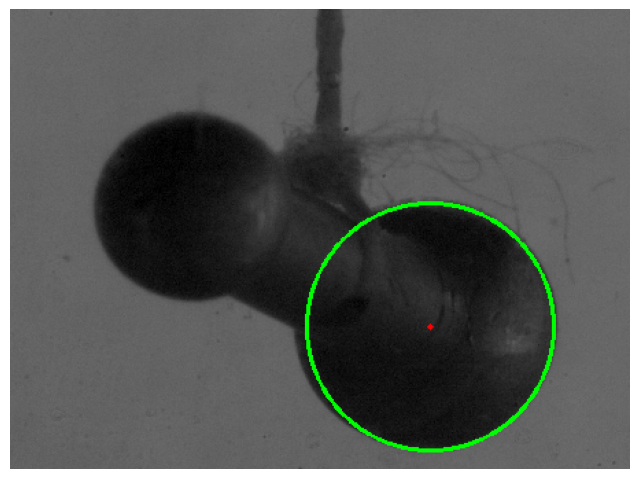

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path = r"D:\0.Code\OpenLPTGUI\OpenLPT\.opencode\attachments\ses_3b63edecaffeURu0n3HuOhX2RQ\5e1fd2661345654c\img-1770771911604-axol0e.png"

# fitted circle (px)
cx, cy, r = 306.29, 230.70, 90.01

img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# draw overlay
overlay = img_rgb.copy()
cv2.circle(overlay, (int(round(cx)), int(round(cy))), int(round(r)), (0, 255, 0), 2)
cv2.circle(overlay, (int(round(cx)), int(round(cy))), 2, (255, 0, 0), -1)

plt.figure(figsize=(8, 6))
plt.imshow(overlay)
plt.axis("off")
plt.show()


Loaded: H:\20260210\T0\Round1\camFile\cam0.txt
Resolution: 1280 x 800
Type: CameraType.PINPLATE

[Line] Projected 200/200 points
[Line] Straightness (px):
  perp RMSE: 0.0107
  perp MAX : 0.0256
[Line] Curvature indicator (t vs s in PCA coords):
  RMSE linear   : 0.0107
  RMSE quadratic: 0.0008
  improvement   : 0.0099


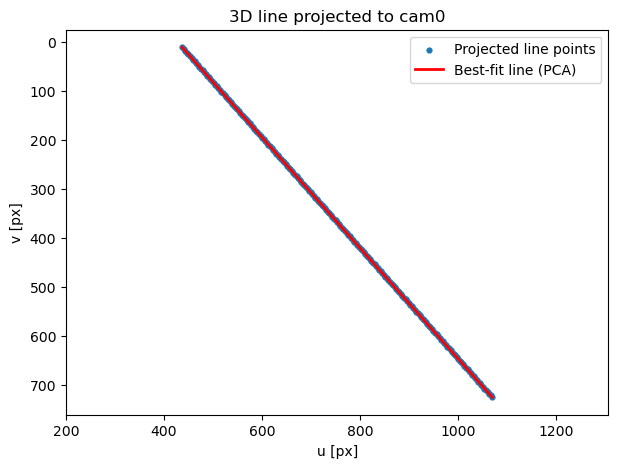

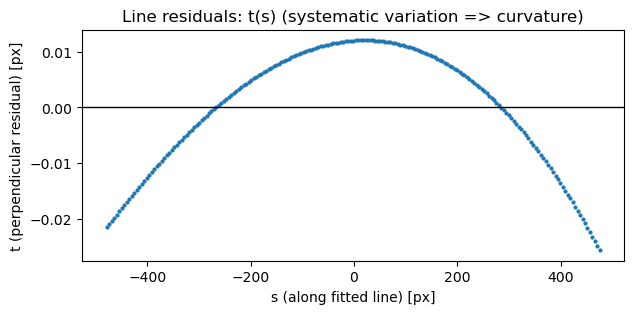


[Circle] Projected 360/360 points

[Circle] Center shift (image):
  proj(center_3d) = (1016.075, 754.499)
  fit-circle ctr  = (1016.093, 754.562)
  delta (u,v)     = (0.018, 0.063) px
  |delta|         = 0.065 px
  mean(uv)        = (1016.085, 754.527)
  fit - mean      = (0.009, 0.035) px
[Circle] Circularity (px):
  fitted center: (1016.09, 754.56)
  fitted radius: 140.32
  radial RMSE  : 0.1844
  radial p95   : 0.2598
  radial MAX   : 0.2612
  PCA axis ratio proxy: 1.0037 (1.0 is perfect)


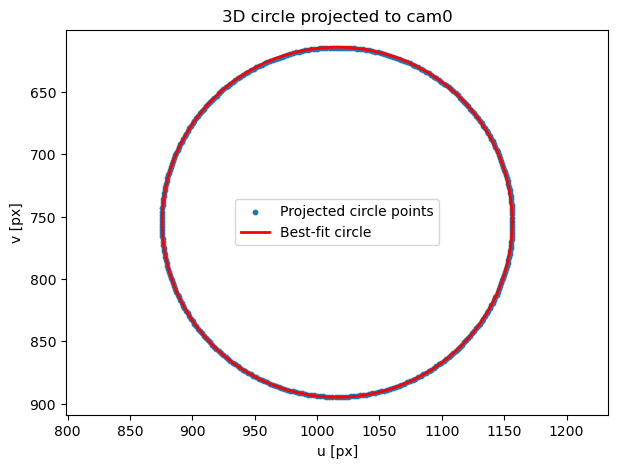

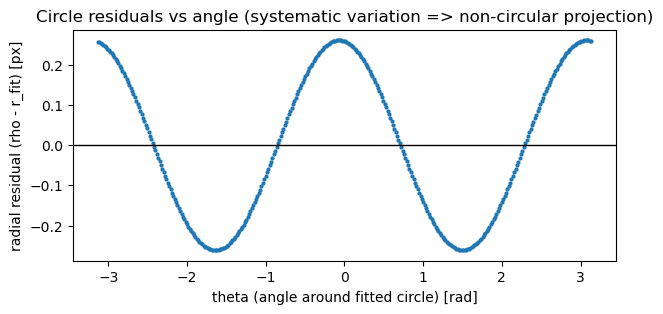

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import openlpt as lpt

# -----------------------------
# Load camera 0 (refraction plate model already baked in)
# -----------------------------
cam_dir = r"H:\20260210\T0\Round1\camFile"
cam0_path = os.path.join(cam_dir, "cam0.txt")

cam0 = lpt.Camera()
cam0.loadParameters(cam0_path)
print("Loaded:", cam0_path)
print("Resolution:", cam0.getNCol(), "x", cam0.getNRow())
print("Type:", cam0._type)

# -----------------------------
# Helpers
# -----------------------------
def project_points(cam, Xs):
    uv = []
    X_ok = []
    for X in Xs:
        pt = lpt.Pt3D(float(X[0]), float(X[1]), float(X[2]))
        uv_pt = cam.project(pt)
        u = float(uv_pt[0])
        v = float(uv_pt[1])
        if np.isfinite(u) and np.isfinite(v):
            uv.append([u, v])
            X_ok.append(X)
    return np.asarray(X_ok, dtype=float), np.asarray(uv, dtype=float)

def analyze_line_straightness(uv):
    # Best-fit 2D line via PCA
    mu = uv.mean(axis=0)
    A = uv - mu
    _, _, Vt = np.linalg.svd(A, full_matrices=False)
    direction = Vt[0]
    direction = direction / np.linalg.norm(direction)
    normal = np.array([-direction[1], direction[0]])

    s = A @ direction
    t = A @ normal  # signed perpendicular residual

    perp_rmse = float(np.sqrt(np.mean(t**2)))
    perp_max = float(np.max(np.abs(t)))

    # Curvature indicator: does quadratic t(s) fit much better than linear?
    m1, c1 = np.polyfit(s, t, 1)
    t1 = m1 * s + c1
    rmse_linear = float(np.sqrt(np.mean((t - t1) ** 2)))

    a2, b2, c2 = np.polyfit(s, t, 2)
    t2 = a2 * s**2 + b2 * s + c2
    rmse_quadratic = float(np.sqrt(np.mean((t - t2) ** 2)))

    return {
        "mu": mu, "direction": direction, "normal": normal,
        "s": s, "t": t,
        "perp_rmse": perp_rmse, "perp_max": perp_max,
        "rmse_linear_ts": rmse_linear, "rmse_quadratic_ts": rmse_quadratic,
        "quad_improvement": rmse_linear - rmse_quadratic,
    }

def fit_circle_kasa(uv):
    # Fit: x^2 + y^2 + a x + b y + c = 0
    x = uv[:, 0]
    y = uv[:, 1]
    A = np.column_stack([x, y, np.ones_like(x)])
    b = -(x*x + y*y)
    a, bb, c = np.linalg.lstsq(A, b, rcond=None)[0]
    cx = -a / 2.0
    cy = -bb / 2.0
    r2 = cx*cx + cy*cy - c
    r = float(np.sqrt(max(r2, 0.0)))
    return float(cx), float(cy), r

def circle_residual_stats(uv, cx, cy, r):
    d = np.sqrt((uv[:, 0] - cx)**2 + (uv[:, 1] - cy)**2)
    e = d - r
    ae = np.abs(e)
    return {
        "rmse": float(np.sqrt(np.mean(e**2))),
        "mae": float(np.mean(ae)),
        "p95": float(np.percentile(ae, 95)),
        "max": float(np.max(ae)),
    }

def pca_axis_ratio_proxy(uv):
    # Cov eigenvalues -> axis ratio proxy (1.0 means isotropic)
    A = uv - uv.mean(axis=0)
    C = (A.T @ A) / max(1, len(uv) - 1)
    w, _ = np.linalg.eigh(C)
    w = np.sort(w)
    if w[0] <= 1e-12:
        return np.inf
    return float(np.sqrt(w[1] / w[0]))

# -----------------------------
# Test 1: 3D line -> project -> check straightness
# -----------------------------
# Line endpoints within ~20x20x20 mm cube centered at origin
# If you get too few valid projected points, increase Z (or whatever your "in front" axis is).
P0 = np.array([-8.0, -6.0,  2.0])  # mm
P1 = np.array([ 8.0,  6.0,  8.0])  # mm

N_line = 200
tt = np.linspace(0.0, 1.0, N_line)
X_line = P0[None, :] + tt[:, None] * (P1 - P0)[None, :]

_, uv_line = project_points(cam0, X_line)
print(f"\n[Line] Projected {len(uv_line)}/{len(X_line)} points")

if len(uv_line) >= 10:
    line_stats = analyze_line_straightness(uv_line)
    print("[Line] Straightness (px):")
    print(f"  perp RMSE: {line_stats['perp_rmse']:.4f}")
    print(f"  perp MAX : {line_stats['perp_max']:.4f}")
    print("[Line] Curvature indicator (t vs s in PCA coords):")
    print(f"  RMSE linear   : {line_stats['rmse_linear_ts']:.4f}")
    print(f"  RMSE quadratic: {line_stats['rmse_quadratic_ts']:.4f}")
    print(f"  improvement   : {line_stats['quad_improvement']:.4f}")

    mu = line_stats["mu"]
    direction = line_stats["direction"]
    s = line_stats["s"]
    smin, smax = float(s.min()), float(s.max())
    p0 = mu + smin * direction
    p1 = mu + smax * direction

    plt.figure(figsize=(7, 5))
    plt.scatter(uv_line[:, 0], uv_line[:, 1], s=12, label="Projected line points")
    plt.plot([p0[0], p1[0]], [p0[1], p1[1]], "r-", lw=2, label="Best-fit line (PCA)")
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.xlabel("u [px]")
    plt.ylabel("v [px]")
    plt.title("3D line projected to cam0")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.plot(line_stats["s"], line_stats["t"], ".", ms=4)
    plt.axhline(0, color="k", lw=1)
    plt.xlabel("s (along fitted line) [px]")
    plt.ylabel("t (perpendicular residual) [px]")
    plt.title("Line residuals: t(s) (systematic variation => curvature)")
    plt.show()
else:
    print("[Line] Too few valid projected points; adjust P0/P1 (especially Z).")

# -----------------------------
# Test 2: 3D circle -> project -> check circularity
# Circle plane is perpendicular to camera optical axis
# -----------------------------

# Circle center inside ~20x20x20 mm cube (edge/corner)
C = np.array([7.0, 7.0, 6.0])   # near +X,+Y corner (10 - R = 7)
R = 3.0                         # mm

# Get optical axis from cam0 (PINPLATE param), consistent with refraction_calibration_BA
pp = cam0._pinplate_param
pp.proj_nmax, pp.proj_tol = 1000, 1e-7
cam0._pinplate_param = pp
cam0.updatePinPlateParam()

R_mtx = np.array([[pp.r_mtx[i, j] for j in range(3)] for i in range(3)], dtype=float)
n = R_mtx[2, :]                 # optical axis in world coords (3rd row)
n = n / np.linalg.norm(n)

# Orthonormal basis (u,v) spanning circle plane (perp to n)
tmp = np.array([1.0, 0.0, 0.0]) if abs(n[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
u = np.cross(n, tmp); u = u / np.linalg.norm(u)
v = np.cross(n, u)

N_circ = 360
ang = np.linspace(0, 2*np.pi, N_circ, endpoint=False)
X_circ = C[None, :] + R*np.cos(ang)[:, None]*u[None, :] + R*np.sin(ang)[:, None]*v[None, :]

_, uv_circ = project_points(cam0, X_circ)
print(f"\n[Circle] Projected {len(uv_circ)}/{len(X_circ)} points")


if len(uv_circ) >= 20:
    cx, cy, rr = fit_circle_kasa(uv_circ)

    # Project the 3D circle center
    C_pt = lpt.Pt3D(float(C[0]), float(C[1]), float(C[2]))
    uvC_pt = cam0.project(C_pt)
    uvC = np.array([float(uvC_pt[0]), float(uvC_pt[1])])

    # Center shift: fitted center vs projected 3D center
    delta = np.array([cx, cy]) - uvC
    shift_mag = float(np.linalg.norm(delta))

    print("\n[Circle] Center shift (image):")
    print(f"  proj(center_3d) = ({uvC[0]:.3f}, {uvC[1]:.3f})")
    print(f"  fit-circle ctr  = ({cx:.3f}, {cy:.3f})")
    print(f"  delta (u,v)     = ({delta[0]:.3f}, {delta[1]:.3f}) px")
    print(f"  |delta|         = {shift_mag:.3f} px")

    uv_mean = uv_circ.mean(axis=0)
    print(f"  mean(uv)        = ({uv_mean[0]:.3f}, {uv_mean[1]:.3f})")
    print(f"  fit - mean      = ({(cx-uv_mean[0]):.3f}, {(cy-uv_mean[1]):.3f}) px")


    cstats = circle_residual_stats(uv_circ, cx, cy, rr)
    axis_ratio = pca_axis_ratio_proxy(uv_circ)

    print("[Circle] Circularity (px):")
    print(f"  fitted center: ({cx:.2f}, {cy:.2f})")
    print(f"  fitted radius: {rr:.2f}")
    print(f"  radial RMSE  : {cstats['rmse']:.4f}")
    print(f"  radial p95   : {cstats['p95']:.4f}")
    print(f"  radial MAX   : {cstats['max']:.4f}")
    print(f"  PCA axis ratio proxy: {axis_ratio:.4f} (1.0 is perfect)")

    plt.figure(figsize=(7, 5))
    plt.scatter(uv_circ[:, 0], uv_circ[:, 1], s=10, label="Projected circle points")
    aa = np.linspace(0, 2*np.pi, 400)
    plt.plot(cx + rr*np.cos(aa), cy + rr*np.sin(aa), "r-", lw=2, label="Best-fit circle")
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.xlabel("u [px]")
    plt.ylabel("v [px]")
    plt.title("3D circle projected to cam0")
    plt.legend()
    plt.show()
else:
    print("[Circle] Too few valid projected points; adjust C/R (especially Z).")

# --- Circle "residual vs angle" plot (analogous to line t(s)) ---
dx = uv_circ[:, 0] - cx
dy = uv_circ[:, 1] - cy
rho = np.sqrt(dx*dx + dy*dy)
rad_res = rho - rr
theta = np.arctan2(dy, dx)  # [-pi, pi]

# Sort by angle for a clean curve
order = np.argsort(theta)
theta_s = theta[order]
res_s = rad_res[order]

plt.figure(figsize=(7, 3))
plt.plot(theta_s, res_s, ".", ms=4)
plt.axhline(0, color="k", lw=1)
plt.xlabel("theta (angle around fitted circle) [rad]")
plt.ylabel("radial residual (rho - r_fit) [px]")
plt.title("Circle residuals vs angle (systematic variation => non-circular projection)")
plt.show()



### Synthetic test for calibraiton

In [10]:
import os
import csv
import glob
import numpy as np
import openlpt as lpt

# --- Settings ---
cam_dir = r"H:\20260210\T0\Round1\camFile"
out_csv = r"H:\20260210\T0\synthetic_wand_points.csv"

N_pairs = 2500
wand_len = 10.0
R_small = 1.5  # mm
R_large = 2.0  # mm

# --- Load all cameras ---
cam_files = sorted(glob.glob(os.path.join(cam_dir, "cam*.txt")))
if not cam_files:
    raise FileNotFoundError(f"No cam*.txt found in {cam_dir}")

cams = {}
for path in cam_files:
    name = os.path.basename(path)
    # Extract integer id from camX.txt
    cid_str = name.replace("cam", "").replace(".txt", "")
    cid = int(cid_str)
    cam = lpt.Camera()
    cam.loadParameters(path)
    cams[cid] = cam

cam_ids = sorted(cams.keys())
print("Loaded cameras:", cam_ids)

# --- Helper: project point and compute pixel radius ---
def estimate_radius_px(cam, X, R_mm):
    """
    Estimate pixel radius for a 3D sphere of radius R_mm at X
    using finite differences and cam.project only.
    Returns NaN if projection fails.
    """
    X = np.asarray(X, dtype=float)

    # Project center
    ptC = lpt.Pt3D(float(X[0]), float(X[1]), float(X[2]))
    uvC = cam.project(ptC)
    u0, v0 = float(uvC[0]), float(uvC[1])
    if not np.isfinite(u0) or not np.isfinite(v0):
        return np.nan

    # Use camera line-of-sight direction to build tangent basis
    # Approx: dir = (X - C), where C from pinplate param
    pp = cam._pinplate_param
    C = np.array([pp.t_vec_inv[0], pp.t_vec_inv[1], pp.t_vec_inv[2]], dtype=float)
    dir_vec = X - C
    norm = np.linalg.norm(dir_vec)
    if not np.isfinite(norm) or norm < 1e-9:
        return np.nan
    dir_vec /= norm

    # Build two orthonormal tangents
    tmp = np.array([1.0, 0.0, 0.0]) if abs(dir_vec[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    t1 = np.cross(dir_vec, tmp); t1 /= np.linalg.norm(t1)
    t2 = np.cross(dir_vec, t1)

    # Project ±R along tangents
    def proj_offset(t):
        Xp = X + R_mm * t
        Xm = X - R_mm * t
        up = cam.project(lpt.Pt3D(float(Xp[0]), float(Xp[1]), float(Xp[2])))
        um = cam.project(lpt.Pt3D(float(Xm[0]), float(Xm[1]), float(Xm[2])))
        up = np.array([float(up[0]), float(up[1])], dtype=float)
        um = np.array([float(um[0]), float(um[1])], dtype=float)
        if np.any(~np.isfinite(up)) or np.any(~np.isfinite(um)):
            return np.nan
        return 0.5 * np.linalg.norm(up - um)

    r1 = proj_offset(t1)
    r2 = proj_offset(t2)

    if not np.isfinite(r1) and not np.isfinite(r2):
        return np.nan
    if not np.isfinite(r1):
        return r2
    if not np.isfinite(r2):
        return r1
    return 0.5 * (r1 + r2)

def project_with_radius(cam, X, R_mm):
    pt = lpt.Pt3D(float(X[0]), float(X[1]), float(X[2]))
    uv = cam.project(pt)
    u = float(uv[0])
    v = float(uv[1])
    if not np.isfinite(u) or not np.isfinite(v):
        return None
    r_px = estimate_radius_px(cam, X, R_mm)
    if not np.isfinite(r_px):
        return None
    return (u, v, float(r_px))

# --- Generate valid wand pairs ---
rows = []
frame_id = 0

rng = np.random.default_rng(42)

def random_unit_vector():
    v = rng.normal(size=3)
    v /= np.linalg.norm(v)
    return v

while frame_id < N_pairs:
    # random center within cube, but ensure endpoints stay inside [-10,10]
    # use center in [-5,5] so ±5 stays inside
    C = rng.uniform(-5.0, 5.0, size=3)
    d = random_unit_vector()
    A = C - 0.5 * wand_len * d
    B = C + 0.5 * wand_len * d

    # ensure inside 20x20x20 cube centered at origin
    if np.any(A < -10) or np.any(A > 10) or np.any(B < -10) or np.any(B > 10):
        continue

    # Project for all cams; if any cam fails, reject this pair
    projections = {}
    valid = True
    for cid in cam_ids:
        cam = cams[cid]
        proj_s = project_with_radius(cam, A, R_small)
        proj_l = project_with_radius(cam, B, R_large)
        if (proj_s is None) or (proj_l is None):
            valid = False
            break
        projections[cid] = (proj_s, proj_l)

    if not valid:
        continue    

    # Store rows: Filtered_Small (PointIdx=0), Filtered_Large (PointIdx=1)
    for cid in cam_ids:
        (u_s, v_s, r_s), (u_l, v_l, r_l) = projections[cid]
        rows.append([frame_id, cid, "Filtered_Small", 0, f"{u_s:.3f}", f"{v_s:.3f}", f"{r_s:.3f}", "0"])
        rows.append([frame_id, cid, "Filtered_Large", 1, f"{u_l:.3f}", f"{v_l:.3f}", f"{r_l:.3f}", "0"])

    frame_id += 1
    if frame_id % 100 == 0:
        print(f"Generated frame {frame_id}/{N_pairs}", end="\r")

print("Generated frames:", frame_id)
print("Total rows:", len(rows))

# --- Write CSV ---
with open(out_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Frame", "Camera", "Status", "PointIdx", "X", "Y", "Radius", "Metric"])
    writer.writerows(rows)

print("Saved:", out_csv)


Loaded cameras: [0, 1, 2, 3]
Generated frames: 2500500
Total rows: 20000
Saved: H:\20260210\T0\synthetic_wand_points.csv


### fixed 3D point calibration


In [3]:
import numpy as np
import cv2
import openlpt as lpt
from scipy.optimize import least_squares

from refractive_geometry import (
    build_pinplate_ray_cpp, triangulate_point, point_to_ray_dist,
    update_cpp_camera_state
)

cams = load_cameras()  # assumes this sets `cams` and `dataset`

# -----------------------------
# 0) Config
# -----------------------------
cam_to_window = {0: 0, 1: 1, 2: 1}
wand_length = 10.0

use_proj_residual = True
frame_stride = 1
max_frames = None

sigma_ray_mm = 0.01
sigma_proj_px = 1.0

margin_mm = 0.05
rA_mm, rB_mm = 1.5, 2.0
w_side = 5e4

# Endpoint selection
KEEP_FRACTION = 1.0
COND_MAX = 1e6
LEN_TOL_MM = 0.3  # only applied if both endpoints exist

# -----------------------------
# 1) Freeze 3D points (one-time triangulation)
# -----------------------------
frames_all = dataset["frames"][::frame_stride]
if max_frames is not None:
    frames_all = frames_all[:max_frames]

endpoint_samples = []  # list of {fid, endpoint, X, cids, tri_err}
pair_info = {}         # fid -> {"A": X, "B": X}

for fid in frames_all:
    for endpoint, obs_key in [("A", "obsA"), ("B", "obsB")]:
        obs = dataset[obs_key].get(fid, {})
        cids = [cid for cid in obs.keys() if cid in cams]
        rays = [build_pinplate_ray_cpp(cams[cid], obs[cid], cam_id=cid, frame_id=fid, endpoint=endpoint) for cid in cids]
        rays_v = [r for r in rays if r.valid]
        if len(rays_v) < 2:
            continue

        X, cond, ok, msg = triangulate_point(rays_v)
        if (not ok) or (cond > COND_MAX):
            continue

        tri_err = float(np.mean([point_to_ray_dist(X, r.o, r.d) for r in rays_v]))

        endpoint_samples.append({
            "fid": fid, "endpoint": endpoint, "X": X, "cids": cids, "tri_err": tri_err
        })
        pair_info.setdefault(fid, {})[endpoint] = X

# length filter (only if both endpoints exist)
good_pairs = set()
for fid, pts in pair_info.items():
    if "A" in pts and "B" in pts:
        L = np.linalg.norm(pts["A"] - pts["B"])
        if abs(L - wand_length) <= LEN_TOL_MM:
            good_pairs.add(fid)

# allow single-endpoint frames
filtered_samples = []
for s in endpoint_samples:
    fid = s["fid"]
    if fid in good_pairs:
        filtered_samples.append(s)
    else:
        if fid not in pair_info or len(pair_info[fid]) == 1:
            filtered_samples.append(s)

# keep top fraction by triangulation error
filtered_samples.sort(key=lambda d: d["tri_err"])
keep_n = int(len(filtered_samples) * KEEP_FRACTION)
filtered_samples = filtered_samples[:keep_n]

# build fixed3d endpoint-level dict
fixed3d = {}  # fixed3d[fid] = {"A": (X,cids), "B": (X,cids)}
for s in filtered_samples:
    fixed3d.setdefault(s["fid"], {})
    fixed3d[s["fid"]][s["endpoint"]] = (s["X"], s["cids"])

print(f"Endpoint samples kept: {len(filtered_samples)} / {len(endpoint_samples)}")
print(f"Frames represented: {len(fixed3d)}")

# -----------------------------
# 2) Extract base camera/window params (from C++ pinplate_param)
# -----------------------------
cams_cpp = cams

cam_params = {}
window_planes = {}
window_media = {}

for cid, cam in cams_cpp.items():
    pp = cam._pinplate_param
    pp.proj_nmax, pp.proj_tol = 1000, 1e-7
    cam._pinplate_param = pp
    cam.updatePinPlateParam()

    Rm = np.array([[pp.r_mtx[i, j] for j in range(3)] for i in range(3)], dtype=float)
    rvec = cv2.Rodrigues(Rm)[0].reshape(-1)
    tvec = np.array([pp.t_vec[i] for i in range(3)], dtype=float)

    fx = float(pp.cam_mtx[0, 0])
    cx = float(pp.cam_mtx[0, 2])
    cy = float(pp.cam_mtx[1, 2])
    k1 = float(pp.dist_coeff[0]) if len(pp.dist_coeff) > 0 else 0.0
    k2 = float(pp.dist_coeff[1]) if len(pp.dist_coeff) > 1 else 0.0

    cam_params[cid] = np.array([*rvec, *tvec, fx, cx, cy, k1, k2], dtype=float)

    wid = cam_to_window[cid]
    if wid not in window_planes:
        n_opt = np.array([pp.plane.norm_vector[0], pp.plane.norm_vector[1], pp.plane.norm_vector[2]], dtype=float)
        pt_farthest = np.array([pp.plane.pt[0], pp.plane.pt[1], pp.plane.pt[2]], dtype=float)
        thick = float(pp.w_array[0]) if pp.w_array and len(pp.w_array) > 0 else 0.0
        window_planes[wid] = {"plane_n": n_opt, "plane_pt": pt_farthest - n_opt * thick}

        refr = pp.refract_array
        window_media[wid] = {"thickness": thick, "n_object": refr[0], "n_window": refr[1], "n_air": refr[2]}

active_cams = sorted([cid for cid in cam_params.keys() if cid in cam_to_window])
active_wins = sorted(list(set(cam_to_window[cid] for cid in active_cams)))

# fixed window planes (NO optimization for planes)
fixed_planes = {
    wid: {
        "plane_n": window_planes[wid]["plane_n"].copy(),
        "plane_pt": window_planes[wid]["plane_pt"].copy()
    } for wid in active_wins
}

base_ext = {cid: cam_params[cid][:6].copy() for cid in active_cams}

# -----------------------------
# 3) Objective: fixed 3D + fixed planes -> optimize camera extrinsics only
# -----------------------------
call_count = 0

def objective(x):
    global call_count
    call_count += 1

    s_invalid = 0.0
    n_invalid = 0
    s_plane = 0.0
    n_plane = 0

    # (a) update C++ camera states using fixed plane geometry
    for i, cid in enumerate(active_cams):
        dx = x[6*i : 6*i+6]
        rv = base_ext[cid][:3] + dx[:3]
        tv = base_ext[cid][3:] + dx[3:]
        wid = cam_to_window[cid]

        update_cpp_camera_state(
            cams_cpp[cid],
            extrinsics={"rvec": rv, "tvec": tv},
            plane_geom={
                "pt": fixed_planes[wid]["plane_pt"].tolist(),
                "n": fixed_planes[wid]["plane_n"].tolist()
            },
        )

    # (b) residuals
    res = []
    sr = 0.0
    nr = 0
    spr = 0.0
    npr = 0
    all_sX = []

    for fid, info in fixed3d.items():
        for endpoint, r_mm, obs_key in [("A", rA_mm, "obsA"), ("B", rB_mm, "obsB")]:
            if endpoint not in info:
                continue

            X, cids = info[endpoint]
            obs = dataset[obs_key].get(fid, {})
            cids = [cid for cid in cids if cid in cams_cpp and cid in obs]

            # ray residuals
            for cid in cids:
                ray = build_pinplate_ray_cpp(
                    cams_cpp[cid], obs[cid],
                    cam_id=cid, window_id=cam_to_window[cid], frame_id=fid, endpoint=endpoint
                )
                if ray.valid:
                    d = point_to_ray_dist(X, ray.o, ray.d)
                    res.append(d / sigma_ray_mm)
                    sr += d*d
                    nr += 1
                else:
                    res.append(10.0)
                    s_invalid += 10.0**2
                    n_invalid += 1

            # optional reprojection residuals
            if use_proj_residual and len(cids) > 0:
                pt_cpp = lpt.Pt3D(float(X[0]), float(X[1]), float(X[2]))
                for cid in cids:
                    uv = cams_cpp[cid].project(pt_cpp)
                    u, v = float(uv[0]), float(uv[1])
                    if np.isfinite(u) and np.isfinite(v):
                        du = (obs[cid][0] - u) / sigma_proj_px
                        dv = (obs[cid][1] - v) / sigma_proj_px
                        res.extend([du, dv])
                        spr += (obs[cid][0] - u)**2 + (obs[cid][1] - v)**2
                        npr += 2
                    else:
                        res.extend([10.0, 10.0])

            # side constraint against fixed planes
            for wid in active_wins:
                n_w = fixed_planes[wid]["plane_n"]
                p_w = fixed_planes[wid]["plane_pt"]
                sX = float(np.dot(n_w, X - p_w))
                all_sX.append(sX)

                gap = (margin_mm + r_mm) - sX
                if gap > 0:
                    clp = min(gap, 50.0)
                    r1 = 10.0 * (1.0 - np.exp(-clp / 0.01))
                    r2 = w_side * clp
                    res.extend([r1, r2])
                    s_plane += r1**2 + r2**2
                    n_plane += 2
                else:
                    res.extend([0.0, 0.0])

    if call_count % 5 == 0:
        ray_rmse = np.sqrt(sr / max(1, nr))
        proj_rmse = np.sqrt(spr / max(1, npr)) if npr > 0 else 0.0
        inv_rmse = np.sqrt(s_invalid / max(1, n_invalid))
        pln_rmse = np.sqrt(s_plane / max(1, n_plane))
        msX = np.min(all_sX) if all_sX else 0.0
        print(
            f"Iter {call_count:4d} | Cost {0.5*np.sum(np.square(res)):.3e} | "
            f"RayRMSE {ray_rmse:.4f}mm | ProjRMSE {proj_rmse:.3f}px | "
            f"InvalidRMSE {inv_rmse:.3f} | PlaneRMSE {pln_rmse:.3f} | min(sX) {msX:.3f}"
        )

    return np.asarray(res, dtype=float)

# -----------------------------
# 4) Run least squares (camera-only variables)
# -----------------------------
cam_params_before = {cid: cam_params[cid].copy() for cid in cam_params}

x0 = np.zeros(6 * len(active_cams))

lb, ub = [], []
for _ in active_cams:
    lb.extend([-np.radians(10)] * 3 + [-20.0] * 3)
    ub.extend([ np.radians(10)] * 3 + [ 20.0] * 3)

print("Starting fixed-3D + fixed-plane optimization (camera-only)...")
result = least_squares(objective, x0, bounds=(lb, ub), method="trf", ftol=1e-6, max_nfev=40)
print("Done. Status:", result.status, "Cost:", result.cost)

# -----------------------------
# 5) Commit camera updates back into cam_params
# -----------------------------
final_x = result.x
for i, cid in enumerate(active_cams):
    cam_params[cid][:6] += final_x[6*i : 6*i+6]

print("Committed updates to cam_params (C++ cameras were updated during objective).")

# Optional delta report
print("\n--- Camera parameter deltas ---")
for cid in sorted(cam_params.keys()):
    before = cam_params_before[cid]
    after = cam_params[cid]
    dr = np.linalg.norm(after[:3] - before[:3]) * 180.0 / np.pi
    dt = np.linalg.norm(after[3:6] - before[3:6])
    print(f"Cam {cid}: Δrot = {dr:.4f} deg, Δt = {dt:.4f} mm")


Successfully loaded Cam 0 from H:\20260106\T0\Refraction\Calibration11\camFile\cam0.txt
  Type: CameraType.PINPLATE
  Resolution: 1280x800
Successfully loaded Cam 1 from H:\20260106\T0\Refraction\Calibration11\camFile\cam1.txt
  Type: CameraType.PINPLATE
  Resolution: 1280x800
Successfully loaded Cam 2 from H:\20260106\T0\Refraction\Calibration11\camFile\cam2.txt
  Type: CameraType.PINPLATE
  Resolution: 1280x800

Total loaded cameras: 3
Endpoint samples kept: 4662 / 4662
Frames represented: 2331
Starting fixed-3D + fixed-plane optimization (camera-only)...
Iter    5 | Cost 1.180e+05 | RayRMSE 0.0376mm | ProjRMSE 1.161px | InvalidRMSE 0.000 | PlaneRMSE 0.000 | min(sX) 4.301
Iter   10 | Cost 1.180e+05 | RayRMSE 0.0376mm | ProjRMSE 1.161px | InvalidRMSE 0.000 | PlaneRMSE 0.000 | min(sX) 4.301
Iter   15 | Cost 1.180e+05 | RayRMSE 0.0376mm | ProjRMSE 1.161px | InvalidRMSE 0.000 | PlaneRMSE 0.000 | min(sX) 4.301
Iter   20 | Cost 1.177e+05 | RayRMSE 0.0376mm | ProjRMSE 1.160px | InvalidRMSE 

In [11]:
import numpy as np

def angle_between_normals(n0, n1):
    n0 = n0 / (np.linalg.norm(n0) + 1e-12)
    n1 = n1 / (np.linalg.norm(n1) + 1e-12)
    return float(np.degrees(np.arccos(np.clip(np.dot(n0, n1), -1.0, 1.0))))

# example: window 0 vs window 1
n0 = window_planes[0]["plane_n"]
n1 = window_planes[1]["plane_n"]
angle_deg = angle_between_normals(n0, n1)
print("Angle between window normals:", angle_deg, "deg")


Angle between window normals: 92.23169571352825 deg
